# Setup


In [2]:
%pip install ipywidgets
%pip install duckdb
%pip install matplotlib
%pip install seaborn
%pip install scipy
%matplotlib inline

import sys
sys.path.append('../scripts')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import duckdb

In [4]:
rewrite = duckdb.read_csv("rewrite.csv")
llm = duckdb.read_csv("llm.csv")

In [5]:
gpt5mini = duckdb.query("""select three+two as two, three from rewrite where version = 'v1.1' and model = 'gpt-5-mini'""").fetchall()
gpt5nano = duckdb.query("""select three+two as two, three from rewrite where version = 'v1.1' and model = 'gpt-5-nano'""").fetchall()

price = duckdb.query("""
with prices as (select step, model, rewritten_queries as queries, (output_tokens*output + input_tokens*input) / 1000000 as price from rewrite join llm using(model) where step > 0 and version = 'v1.1')
select p1.step, p1.price, p2.price, p1.queries, p2.queries from prices p1 join prices p2 on p1.step = p2.step and p1.model = 'gpt-5-mini' and p2.model = 'gpt-5-nano' order by p1.step asc
""").fetchall()

price

[(1, 6.1235235, 1.185613175, 4538, 4539),
 (2, 5.0138365, 1.076519725, 3239, 3881),
 (3, 4.2366115, 1.037350325, 2591, 3648)]

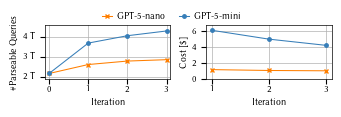

In [12]:
from plot.linestyle import Linestyle
from plot.marker import Marker
from plot.color import Color
from plot.location import Location
from plot.formatter import Decorator, Grid, NumberFormatter, Scale
from plot.lineplot import LinePlot
from plot.frame import Format, GridFrame, Frame, cm2inch, latexify
from matplotlib.patches import Rectangle

x = [0, 1, 2, 3]

latexify(hyperref=False, increase_font=-1)
frame = GridFrame(width=3.3, height=0.9, n_rows=1, n_columns=2)
plot = LinePlot(frame[0, 0])
plot.format_axes(xformatter=NumberFormatter(scale=Scale.LINEAR, min=-0.1, max=3.1, grid=Grid.MAJOR, ticks=x, label="Iteration"),
                 yformatter=NumberFormatter(scale=Scale.LINEAR, min=1900, max=4600, ticks=[2000, 3000, 4000], label="\\#Parseable Queries"))
h1 = plot.plot(x=x, y=[y[0] for y in gpt5nano], color=Color.ORANGE, marker=Marker.CROSS)
# plot.plot(x=x, y=[y[1] for y in gpt5nano], color=Color.ORANGE, marker=Marker.CROSS, linestyle=Linestyle.DASHED)
h2 = plot.plot(x=x, y=[y[0] for y in gpt5mini], color=Color.BLUE, marker=Marker.CIRCLE)
# plot.plot(x=x, y=[y[1] for y in gpt5mini], color=Color.BLUE, marker=Marker.CIRCLE, linestyle=Linestyle.DASHED)

plot = LinePlot(frame[0, 1])
plot.format_axes(xformatter=NumberFormatter(scale=Scale.LINEAR, min=0.9, max=3.1, grid=Grid.MAJOR, ticks=x, label="Iteration"),
                 yformatter=NumberFormatter(scale=Scale.LINEAR, min=0, max=6.75, label="Cost~[\\$]", ticks=[0, 2, 4, 6]))
plot.plot(x=x[1:], y=[y[2] for y in price], color=Color.ORANGE, marker=Marker.CROSS)
plot.plot(x=x[1:], y=[y[1] for y in price], color=Color.BLUE, marker=Marker.CIRCLE)

frame.legend([h1, h2], ["GPT-5-nano", "GPT-5-mini"], bbox_to_anchor=(0.5, 1.05), location=Location.CENTER, columns=3)

frame.save(os.path.join("pdf/rewrite"), format=Format.PDF)